# OpenClaw gateway walkthrough

这个 notebook 解释两件事：

1. `"/context list"` 是什么。
2. `client-harness` 里的 Python 是怎么连接 OpenClaw gateway，并发送这条指令的。

先说结论：`"/context list"` 不是直接发给模型的普通 prompt，而是 OpenClaw 的内置 slash command。命令会先在 OpenClaw 内部被识别和处理，然后返回一份 context breakdown 文本。

## 代码里对应的位置

- `benchmarks/client-harness/scenarios/docker_single.json` 里把 `client.message` 设成了 `"/context list"`
- `benchmarks/client-harness/src/openclaw_harness/gateway_client.py` 负责连 WebSocket 并发 `chat.send`
- `benchmarks/client-harness/src/openclaw_harness/runner.py` 负责完整调用链：`chat.send -> agent.wait -> chat.history`
- `src/auto-reply/reply/commands-context-report.ts` 负责实现 `/context` 命令

所以 harness 在做的事情，不是“直接调模型 API”，而是“模拟一个 gateway 客户端，通过 OpenClaw 的网关协议发消息”。

In [ ]:
from pathlib import Path
import json

repo_root = Path.cwd().resolve()
if (repo_root / "client-harness").exists():
    pass
elif (repo_root / "client-harness").exists():
    repo_root = repo_root.parent
elif repo_root.name == "benchmarks" and (repo_root / "client-harness").exists():
    repo_root = repo_root.parent

scenario_path = repo_root / "client-harness" / "scenarios" / "docker_single.json"
scenario = json.loads(scenario_path.read_text(encoding="utf-8"))

scenario["client"]

{'role': 'operator',
 'message': '/context list',
 'session_prefix': 'bench-single',
 'session_mode': 'per_worker',
 'history_limit': 20,
 'wait_timeout_ms': 15000,
 'send_timeout_ms': 15000}

上面这个配置里，`message` 就是 harness 要发送的内容。默认值选 `"/context list"`，是因为它不依赖模型密钥，适合做稳定的基准测试。

In [ ]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if (repo_root / "client-harness").exists():
    pass
elif (repo_root / "client-harness").exists():
    repo_root = repo_root.parent
elif repo_root.name == "benchmarks" and (repo_root / "client-harness").exists():
    repo_root = repo_root.parent

harness_src = repo_root / "client-harness" / "src"
if str(harness_src) not in sys.path:
    sys.path.insert(0, str(harness_src))

from openclaw_harness.gateway_client import GatewayClient
from openclaw_harness.device_identity import load_or_create_device_identity

GatewayClient

openclaw_harness.gateway_client.GatewayClient

## 连接流程

`GatewayClient.connect()` 做了这几步：

1. 用 `websockets.connect(url)` 连到 gateway 的 WebSocket。
2. 等待 gateway 发 `connect.challenge` 事件，里面会带一个 `nonce`。
3. 用本地设备身份对认证 payload 签名。
4. 发送 `connect` 请求，把 token、role、device 信息一起交给 gateway。
5. 连接成功后，再发业务请求，比如 `chat.send`。

这里的设备身份由 `benchmarks/client-harness/.state/device.json` 持久化；如果没有，Python 会调用本机 `node` 生成一对 Ed25519 密钥。

In [11]:
import inspect

print(inspect.getsource(GatewayClient.send_chat))
print("-" * 60)
print(inspect.getsource(GatewayClient.wait_for_agent))
print("-" * 60)
print(inspect.getsource(GatewayClient.load_history))

    async def send_chat(
        self,
        *,
        session_key: str,
        message: str,
        run_id: str,
        timeout_ms: int,
    ) -> GatewayResponse:
        return await self.request(
            "chat.send",
            {
                "sessionKey": session_key,
                "message": message,
                "idempotencyKey": run_id,
                "timeoutMs": timeout_ms,
            },
            timeout_ms=timeout_ms + 5_000,
        )

------------------------------------------------------------
    async def wait_for_agent(self, *, run_id: str, timeout_ms: int) -> GatewayResponse:
        return await self.request(
            "agent.wait",
            {
                "runId": run_id,
                "timeoutMs": timeout_ms,
            },
            timeout_ms=timeout_ms + 5_000,
        )

------------------------------------------------------------
    async def load_history(self, *, session_key: str, limit: int) -> GatewayResponse:
        ret

可以看到，harness 实际发的是 3 个 gateway 方法：

- `chat.send`：把消息送进某个 session
- `agent.wait`：等待这次 run 执行完成
- `chat.history`：把这个 session 的消息历史取回来

而 `"/context list"` 只是 `chat.send` 里的 `message` 字段值。

In [13]:
import asyncio
import os
from uuid import uuid4


async def demo_context_list():
    url = os.environ.get("OPENCLAW_GATEWAY_URL", "ws://127.0.0.1:19189")
    token = os.environ.get("OPENCLAW_GATEWAY_TOKEN", "openclaw-bench-token")
    session_key = os.environ.get("OPENCLAW_SESSION_KEY", "notebook-demo")

    device_identity = load_or_create_device_identity()
    client = GatewayClient(
        url=url,
        token=token,
        role="operator",
        instance_id=f"notebook-{uuid4().hex[:8]}",
        device_identity=device_identity,
    )

    try:
        connect_latency_ms = await client.connect()
        run_id = str(uuid4())

        send_response = await client.send_chat(
            session_key=session_key,
            message="/context list",
            run_id=run_id,
            timeout_ms=15000,
        )
        wait_response = await client.wait_for_agent(run_id=run_id, timeout_ms=15000)
        history_response = await client.load_history(session_key=session_key, limit=20)

        return {
            "connect_latency_ms": round(connect_latency_ms, 3),
            "send_ok": send_response.ok,
            "send_payload": send_response.payload,
            "wait_ok": wait_response.ok,
            "wait_payload": wait_response.payload,
            "history_ok": history_response.ok,
            "history_message_count": len((history_response.payload or {}).get("messages", []) or []),
            "history_payload": history_response.payload,
        }
    finally:
        await client.close()


# 如果本地已经跑了 gateway，可以取消下面一行注释直接试。
result = await demo_context_list()
result

ConnectionRefusedError: [Errno 10061] Connect call failed ('127.0.0.1', 19189)

## 为什么说它不是普通 prompt

OpenClaw 内部会先检查消息是不是命令。`/context list` 命中后，会走 `src/auto-reply/reply/commands-context-report.ts` 里的逻辑，生成 context breakdown 文本。

也就是说，语义上更像：

- 客户端发送一条“命令消息”
- gateway / agent 层识别命令
- OpenClaw 自己生成回复
- 最终这段回复再出现在 chat history 里

它不是简单地把 `"/context list"` 四个词原样扔给底层模型。

In [15]:
summary = {
    "message_sent": "/context list",
    "transport": "WebSocket RPC to OpenClaw gateway",
    "methods": ["connect", "chat.send", "agent.wait", "chat.history"],
    "not_a_plain_model_prompt": True,
}

## docker_single 和 docker_multi 是怎么测的

这两个 scenario 都是 Docker runtime，差别主要在 `load` 配置，不在 `message`。换句话说，它们都是发 `/context list`，只是并发模型不同。

In [ ]:
from pathlib import Path
import json

base = repo_root / "client-harness" / "scenarios"
docker_single = json.loads((base / "docker_single.json").read_text(encoding="utf-8"))
docker_multi = json.loads((base / "docker_multi.json").read_text(encoding="utf-8"))

{
    "docker_single": {
        "message": docker_single["client"]["message"],
        "concurrency": docker_single["load"]["concurrency"],
        "requests_per_worker": docker_single["load"]["requests_per_worker"],
        "worker_stagger_ms": docker_single["load"]["worker_stagger_ms"],
    },
    "docker_multi": {
        "message": docker_multi["client"]["message"],
        "concurrency": docker_multi["load"]["concurrency"],
        "requests_per_worker": docker_multi["load"]["requests_per_worker"],
        "worker_stagger_ms": docker_multi["load"]["worker_stagger_ms"],
    },
}

{'docker_single': {'message': '/context list',
  'concurrency': 1,
  'requests_per_worker': 3,
  'worker_stagger_ms': 0},
 'docker_multi': {'message': '/context list',
  'concurrency': 4,
  'requests_per_worker': 2,
  'worker_stagger_ms': 150}}

可以把它理解成：

- `docker_single`：1 个 worker，同一个 worker 连上 gateway 后连续发 3 次 `/context list`
- `docker_multi`：4 个 worker，每个 worker 发 2 次 `/context list`
- 所以 `docker_single` 总请求数是 `1 * 3 = 3`
- `docker_multi` 总请求数是 `4 * 2 = 8`

这里的“单线程 / 多线程”更准确地说是“单 worker / 多 worker 并发”。代码用的是 `asyncio.create_task(...)` 并发地跑多个 worker，不是 Python `threading.Thread` 去做请求并发。

In [17]:
import inspect
from openclaw_harness.runner import execute_load, resolve_session_key

print(inspect.getsource(resolve_session_key))
print("-" * 60)
print(inspect.getsource(execute_load).split("def build_preflight_payload", 1)[0])

def resolve_session_key(
    *,
    scenario: ScenarioConfig,
    worker_id: int,
    request_index: int,
) -> str:
    prefix = scenario.client.session_prefix
    mode = scenario.client.session_mode
    if mode == "shared":
        return f"{prefix}-shared"
    if mode == "per_request":
        return f"{prefix}-w{worker_id}-r{request_index}"
    return f"{prefix}-w{worker_id}"

------------------------------------------------------------
async def execute_load(
    scenario: ScenarioConfig,
    url: str,
    token: str,
    *,
    device_identity,
) -> list[dict[str, object]]:
    records: list[dict[str, object]] = []

    async def worker(worker_id: int) -> None:
        if scenario.load.worker_stagger_ms > 0:
            await asyncio.sleep((scenario.load.worker_stagger_ms * worker_id) / 1000.0)
        client = GatewayClient(
            url=url,
            token=token,
            role=scenario.client.role,
            instance_id=f"{slugify(scenario.name)}-{worker_id}-{uuid4().

从 `execute_load()` 可以看出 single/multi 的关键差别：

- 它会按 `concurrency` 创建多个 worker task
- 每个 worker 先 `connect()` 一次
- 然后按 `requests_per_worker` 循环发 `chat.send -> agent.wait -> chat.history`
- `worker_stagger_ms` 可以让 worker 错开启动，避免全部在同一毫秒冲进去
- `session_mode=per_worker` 意味着同一个 worker 的多次请求会复用同一个 session key

因为 `docker_single` 和 `docker_multi` 都把 `client.message` 设为 `/context list`，所以它们测的是同一种命令在不同并发下的延迟和资源表现。

## out 目录结构是什么

每次 run 都会生成一个独立目录，形如：

- `benchmarks/client-harness/out/20260319T125032Z_docker-single/`

里面文件多，是因为它不只保存“最终分数”，还保存了：

- 场景实际解析后的配置
- 运行时 / 容器的环境与启动信息
- 原始 collector 输出
- parse 后的 collector summary
- 每一次请求的明细 latency

In [ ]:
sample_run = repo_root / "client-harness" / "out" / "20260319T125032Z_docker-single"
sorted(str(path.relative_to(sample_run)) for path in sample_run.rglob("*"))[:40]

可以把 `out/<timestamp>_<scenario>/` 里的文件分成几类：

- `scenario.resolved.json`：最终用来跑的 scenario 配置
- `preflight.json`：run 前的可达性 / collector 状态检查
- `latency.csv`：每一次请求的明细记录
- `summary.json`：面向阅读的汇总指标
- `meta.json`：最全面的元数据，包括 runtime、collector、environment 等
- `docker_stats.csv` / `pidstat.log` / `perf_stat.csv` / `perf.data`：collector 原始产物
- `pidstat_*.csv` / `pidstat.summary.json` / `perf_stat.parsed.csv` / `perf_stat.summary.json`：collector parse 后的结果
- `runtime/`：harness 为这次 run 单独准备的 runtime 状态目录

In [ ]:
import json

summary_payload = json.loads((sample_run / "summary.json").read_text(encoding="utf-8"))
meta_payload = json.loads((sample_run / "meta.json").read_text(encoding="utf-8"))

{
    "summary_keys": sorted(summary_payload.keys()),
    "collector_names": [c["name"] for c in meta_payload["collectors"]],
    "runtime_keys": sorted(meta_payload["runtime"].keys()),
}

## 有哪些 metrics

最核心的是 `latency.csv` 和 `summary.json` 里的 latency metrics：

- `connect_latency_ms`：worker 连接 gateway 并完成 `connect` 握手的耗时
- `send_latency_ms`：`chat.send` 这一步的耗时
- `wait_latency_ms`：`agent.wait` 这一步的耗时，通常是最像“业务执行时间”的指标
- `history_latency_ms`：`chat.history` 这一步的耗时
- `total_latency_ms`：一次完整 `send -> wait -> history` 的总耗时
- `history_messages`：这次请求后 session 里有多少条 message
- `success` / `send_status` / `wait_status` / `error`：用来判断是否成功以及失败原因

`summary.json` 会对这些 latency 做聚合，例如 `count / min / max / mean / p50 / p95 / p99`。

In [ ]:
summary_payload["latency_ms"]

collector metrics 则来自额外采样工具：

- `docker_stats.csv`
  - `cpu_percent`
  - `mem_percent`
  - `mem_usage_limit`
  - `net_io`
  - `block_io`
  - `pids`
- `pidstat`
  - CPU: `%usr`, `%system`, `%guest`, `%wait`, `%CPU`
  - Memory: `VSZ`, `RSS`, `%MEM`, major/minor faults
  - IO: `kB_rd/s`, `kB_wr/s`, `kB_ccwr/s`, `iodelay`
- `perf_stat`
  - event counter、runtime、running pct、metric value
- `perf_record`
  - 主要是生成 `perf.data` 供后续 flame graph / hotspot 分析，不是直接给一个简单 latency 数字

如果某个 collector 没有安装或 scenario 关掉了，它会在 `meta.json` 里显示 `skipped`，所以你会看到有些 run 的文件比别的 run 少。

In [ ]:
meta_payload["collectors"]

## runtime 目录为什么也有很多文件

对 Docker scenario 来说，harness 不是直接复用你家里的 `~/.openclaw`，而是为每一次 run 在 `runtime/` 下面准备一个隔离的 runtime 环境，包括：

- `runtime/config/openclaw.json`
- `runtime/config/devices/paired.json`
- `runtime/config/devices/pending.json`
- `runtime/workspace/`：容器内使用的 workspace 挂载点
- `runtime/docker-build.log`
- `runtime/docker-logs.txt`

所以 `out/` 下面文件多，本质上是因为这个 harness 在做“可复现 benchmark 证据归档”，而不只是吐一个 QPS 或 latency 数字。

## 用 DataFrame 对比单 worker 和多 worker 汇总指标

下面这部分会自动读取 `out/` 里最新的 `docker-single` 和 `docker-multi` 结果，把核心汇总指标整理成 DataFrame，然后直接作图。

In [ ]:
from pathlib import Path
import json
import pandas as pd


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / "client-harness" / "out").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the current notebook working directory")


repo_root = resolve_repo_root()
out_root = repo_root / "client-harness" / "out"


def find_latest_run_dir(scenario_name: str) -> Path:
    candidates = sorted(
        [path for path in out_root.iterdir() if path.is_dir() and path.name.endswith(f"_{scenario_name}")],
        key=lambda path: path.name,
    )
    if not candidates:
        raise FileNotFoundError(f"No run directory found for scenario: {scenario_name}")
    return candidates[-1]


single_run_dir = find_latest_run_dir("docker-single")
multi_run_dir = find_latest_run_dir("docker-multi")

single_run_dir, multi_run_dir

(WindowsPath('//wsl.localhost/Ubuntu/home/z84436644/openclaw/benchmarks/client-harness/out/20260319T141651Z_docker-single'),
 WindowsPath('//wsl.localhost/Ubuntu/home/z84436644/openclaw/benchmarks/client-harness/out/20260319T132623Z_docker-multi'))

In [2]:
def load_summary(run_dir: Path) -> dict:
    return json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))


single_summary = load_summary(single_run_dir)
multi_summary = load_summary(multi_run_dir)

single_summary["scenario"], multi_summary["scenario"]

('docker-single', 'docker-multi')

In [4]:
def build_summary_row(summary: dict) -> dict:
    latency = summary["latency_ms"]
    return {
        "scenario": summary["scenario"],
        "requests_total": summary["requests_total"],
        "requests_ok": summary["requests_ok"],
        "requests_failed": summary["requests_failed"],
        "connect_mean_ms": latency["connect"]["mean"],
        "connect_p95_ms": latency["connect"]["p95"],
        "send_mean_ms": latency["send"]["mean"],
        "send_p95_ms": latency["send"]["p95"],
        "wait_mean_ms": latency["wait"]["mean"],
        "wait_p95_ms": latency["wait"]["p95"],
        "history_mean_ms": latency["history"]["mean"],
        "history_p95_ms": latency["history"]["p95"],
        "total_mean_ms": latency["total"]["mean"],
        "total_p50_ms": latency["total"]["p50"],
        "total_p95_ms": latency["total"]["p95"],
        "total_p99_ms": latency["total"]["p99"],
    }


comparison_df = pd.DataFrame([
    build_summary_row(single_summary),
    build_summary_row(multi_summary),
]).set_index("scenario")

comparison_df.round(3).T

scenario,docker-single,docker-multi
requests_total,3.000,8.000
requests_ok,3.000,8.000
requests_failed,0.000,0.000
connect_mean_ms,230.557,153.856
connect_p95_ms,230.557,256.555
send_mean_ms,2.623,13.289
send_p95_ms,4.587,92.920
wait_mean_ms,108.544,82.213
wait_p95_ms,227.159,174.739
history_mean_ms,4.176,3.375


上面这个 DataFrame 是最直接的单 worker / 多 worker 汇总对比表。下面再做几张图，把请求量和各阶段延迟拆开看。

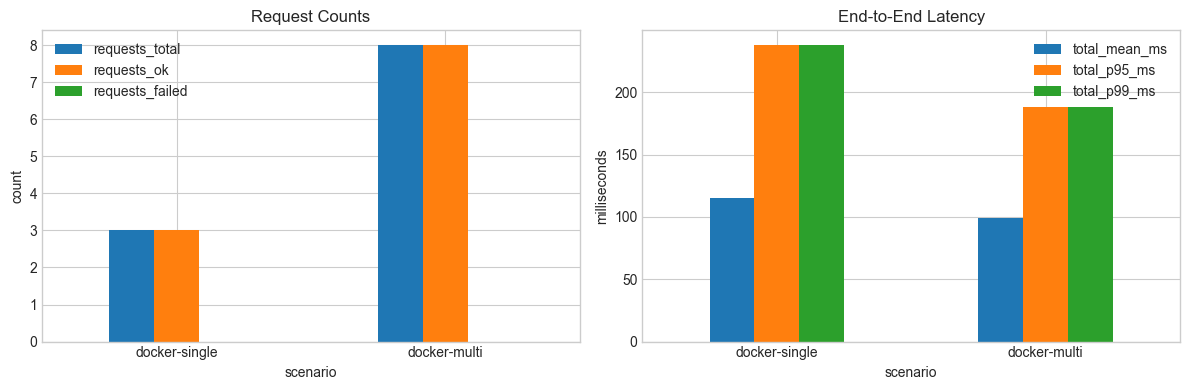

In [6]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

comparison_df[["requests_total", "requests_ok", "requests_failed"]].plot(
    kind="bar",
    ax=axes[0],
    rot=0,
    title="Request Counts",
)
axes[0].set_ylabel("count")

comparison_df[["total_mean_ms", "total_p95_ms", "total_p99_ms"]].plot(
    kind="bar",
    ax=axes[1],
    rot=0,
    title="End-to-End Latency",
)
axes[1].set_ylabel("milliseconds")

plt.tight_layout()
plt.show()

In [7]:
phase_mean_df = comparison_df[[
    "connect_mean_ms",
    "send_mean_ms",
    "wait_mean_ms",
    "history_mean_ms",
    "total_mean_ms",
]].rename(columns={
    "connect_mean_ms": "connect",
    "send_mean_ms": "send",
    "wait_mean_ms": "wait",
    "history_mean_ms": "history",
    "total_mean_ms": "total",
})

phase_mean_df.round(3)

,connect,send,wait,history,total
scenario,,,,,
docker-single,230.557,2.623,108.544,4.176,115.371
docker-multi,153.856,13.289,82.213,3.375,98.910


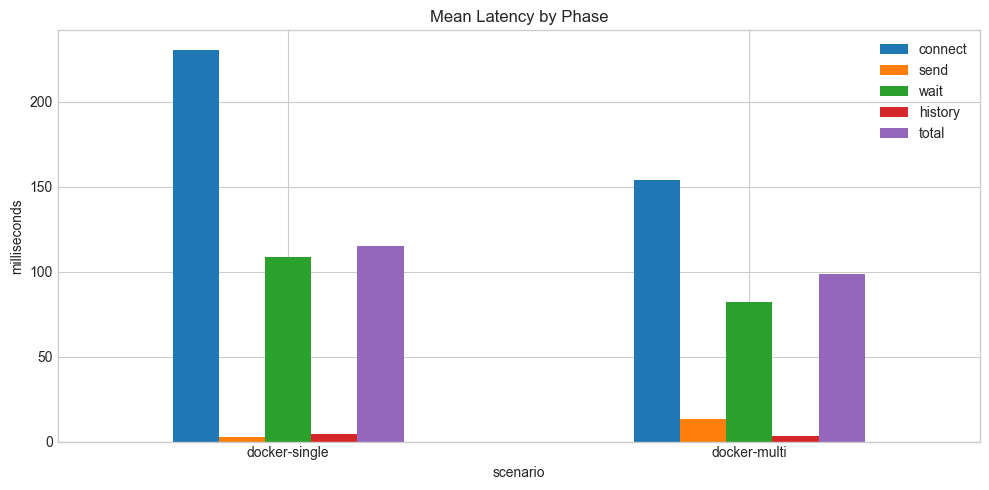

In [18]:
ax = phase_mean_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Mean Latency by Phase")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()

In [19]:
tail_latency_df = comparison_df[["send_p95_ms", "wait_p95_ms", "history_p95_ms", "total_p95_ms"]].rename(columns={
    "send_p95_ms": "send_p95",
    "wait_p95_ms": "wait_p95",
    "history_p95_ms": "history_p95",
    "total_p95_ms": "total_p95",
})

tail_latency_df.round(3)

,send_p95,wait_p95,history_p95,total_p95
scenario,,,,
docker-single,4.587,227.159,6.065,237.842
docker-multi,92.920,174.739,7.853,188.403


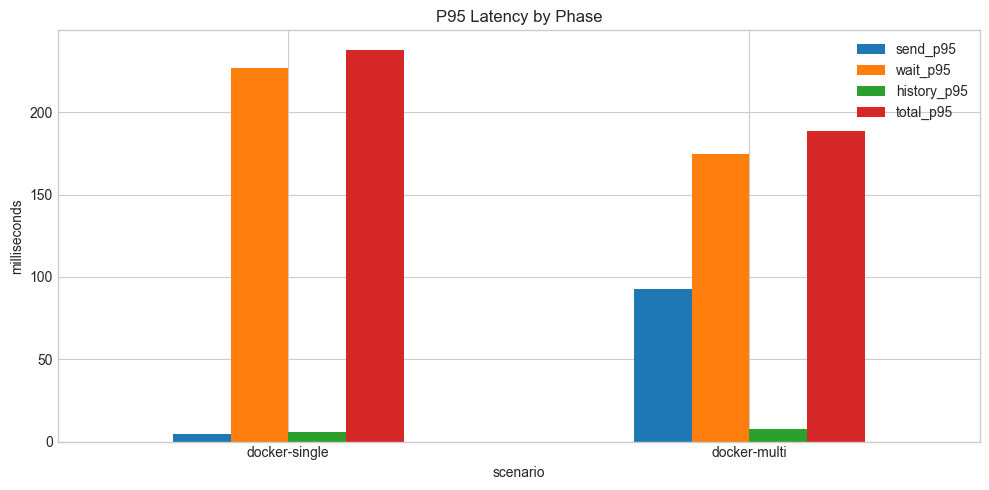

In [20]:
ax = tail_latency_df.plot(kind="bar", figsize=(10, 5), rot=0, title="P95 Latency by Phase")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()

如果你想继续往下钻，还可以把 `latency.csv` 读进 DataFrame，做每个 request 的散点图、箱线图，或者按 worker 拆开看多 worker 场景里的抖动。

## 读取 `*-100-summary` 做大样本对比图

下面这部分专门读取只保留 `summary.json` 的大样本场景：

- `docker-single-100-summary`
- `docker-multi-100-summary`

这样可以更稳定地比较 `1 x 100` 和 `4 x 25` 两种负载模型。

In [29]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / "client-harness" / "out").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the current notebook working directory")


repo_root = resolve_repo_root()
out_root = repo_root / "client-harness" / "out"


def find_latest_run_dir(scenario_name: str) -> Path:
    candidates = sorted(
        [path for path in out_root.iterdir() if path.is_dir() and path.name.endswith(f"_{scenario_name}")],
        key=lambda path: path.name,
    )
    if not candidates:
        raise FileNotFoundError(f"No run directory found for scenario: {scenario_name}")
    return candidates[-1]


def load_summary(run_dir: Path) -> dict:
    return json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))


single_100_run_dir = find_latest_run_dir("docker-single-100-summary")
multi_100_run_dir = find_latest_run_dir("docker-multi-100-summary")
single_100_summary = load_summary(single_100_run_dir)
multi_100_summary = load_summary(multi_100_run_dir)

single_100_run_dir, multi_100_run_dir

(WindowsPath('//wsl.localhost/Ubuntu/home/z84436644/openclaw/benchmarks/client-harness/out/20260320T095040Z_docker-single-100-summary'),
 WindowsPath('//wsl.localhost/Ubuntu/home/z84436644/openclaw/benchmarks/client-harness/out/20260320T095109Z_docker-multi-100-summary'))

In [30]:
def nested_get(data: dict, path: list[str], default=None):
    current = data
    for key in path:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def metric_mean(data: dict, path: list[str], default=None):
    metric = nested_get(data, path, None)
    if isinstance(metric, dict):
        return metric.get("mean", default)
    return default


def build_resource_profile_row(summary: dict) -> dict:
    latency = summary["latency_ms"]
    docker = nested_get(summary, ["collector_analysis", "docker_stats", "metrics"], {})
    pidstat = nested_get(summary, ["collector_analysis", "pidstat", "sections"], {})
    iostat = nested_get(summary, ["collector_analysis", "iostat"], {})
    busiest_device = iostat.get("busiest_device_by_util_mean")
    device_metrics = nested_get(iostat, ["devices", busiest_device, "metrics"], {}) if busiest_device else {}
    return {
        "scenario": summary["scenario"],
        "requests_total": summary["requests_total"],
        "requests_ok": summary["requests_ok"],
        "requests_failed": summary["requests_failed"],
        "connect_mean_ms": latency["connect"]["mean"],
        "send_mean_ms": latency["send"]["mean"],
        "send_p95_ms": latency["send"]["p95"],
        "send_p99_ms": latency["send"]["p99"],
        "wait_mean_ms": latency["wait"]["mean"],
        "wait_p95_ms": latency["wait"]["p95"],
        "wait_p99_ms": latency["wait"]["p99"],
        "history_mean_ms": latency["history"]["mean"],
        "history_p95_ms": latency["history"]["p95"],
        "history_p99_ms": latency["history"]["p99"],
        "total_mean_ms": latency["total"]["mean"],
        "total_p50_ms": latency["total"]["p50"],
        "total_p95_ms": latency["total"]["p95"],
        "total_p99_ms": latency["total"]["p99"],
        "docker_cpu_percent_mean": metric_mean(docker, ["cpu_percent_value"]),
        "docker_mem_percent_mean": metric_mean(docker, ["mem_percent_value"]),
        "docker_block_read_bytes_mean": metric_mean(docker, ["block_read_bytes"]),
        "docker_block_write_bytes_mean": metric_mean(docker, ["block_write_bytes"]),
        "pidstat_cpu_percent_mean": metric_mean(pidstat, ["cpu", "metrics", "pct_cpu"]),
        "pidstat_rss_kib_mean": metric_mean(pidstat, ["memory", "metrics", "rss_kib"]),
        "pidstat_kb_wr_per_s_mean": metric_mean(pidstat, ["io", "metrics", "kb_wr_per_s"]),
        "pidstat_iodelay_mean": metric_mean(pidstat, ["io", "metrics", "iodelay"]),
        "iostat_busiest_device": busiest_device,
        "iostat_pct_util_mean": metric_mean(device_metrics, ["pct_util"]),
        "iostat_await_mean": metric_mean(device_metrics, ["await"]),
        "iostat_w_await_mean": metric_mean(device_metrics, ["w_await"]),
        "iostat_aqu_sz_mean": metric_mean(device_metrics, ["aqu_sz"]),
        "iostat_wkb_s_mean": metric_mean(device_metrics, ["wkb_s"]),
    }


summary_100_df = pd.DataFrame([
    build_resource_profile_row(single_100_summary),
    build_resource_profile_row(multi_100_summary),
]).set_index("scenario")

summary_100_df.round(3).T

scenario,docker-single-100-summary,docker-multi-100-summary
requests_total,100,100
requests_ok,100,100
requests_failed,0,0
connect_mean_ms,263.565,204.198
send_mean_ms,1.101,3.728
send_p95_ms,1.8,3.227
send_p99_ms,3.131,95.978
wait_mean_ms,37.092,132.614
wait_p95_ms,48.738,183.171
wait_p99_ms,74.689,218.64


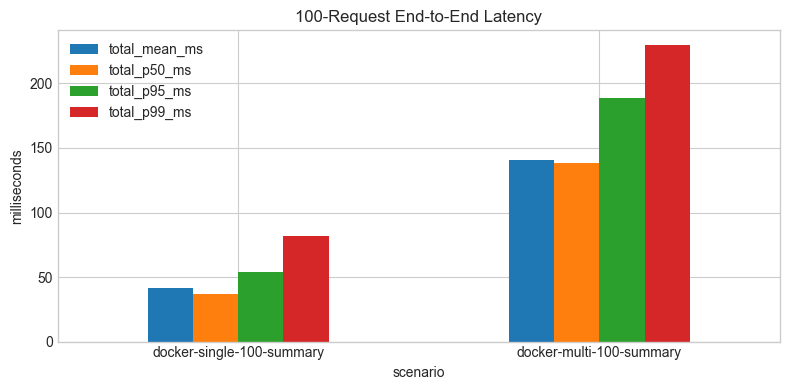

In [31]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 1, figsize=(8, 4))

summary_100_df[["total_mean_ms", "total_p50_ms", "total_p95_ms", "total_p99_ms"]].plot(
    kind="bar",
    ax=axes,
    rot=0,
    title="100-Request End-to-End Latency",
)
axes.set_ylabel("milliseconds")

plt.tight_layout()
plt.show()

In [32]:
phase_100_df = summary_100_df[[
    "connect_mean_ms",
    "send_mean_ms",
    "wait_mean_ms",
    "history_mean_ms",
    "total_mean_ms",
]].rename(columns={
    "connect_mean_ms": "connect",
    "send_mean_ms": "send",
    "wait_mean_ms": "wait",
    "history_mean_ms": "history",
    "total_mean_ms": "total",
})

phase_100_df.round(3)

,connect,send,wait,history,total
scenario,,,,,
docker-single-100-summary,263.565,1.101,37.092,3.154,41.368
docker-multi-100-summary,204.198,3.728,132.614,4.121,140.490


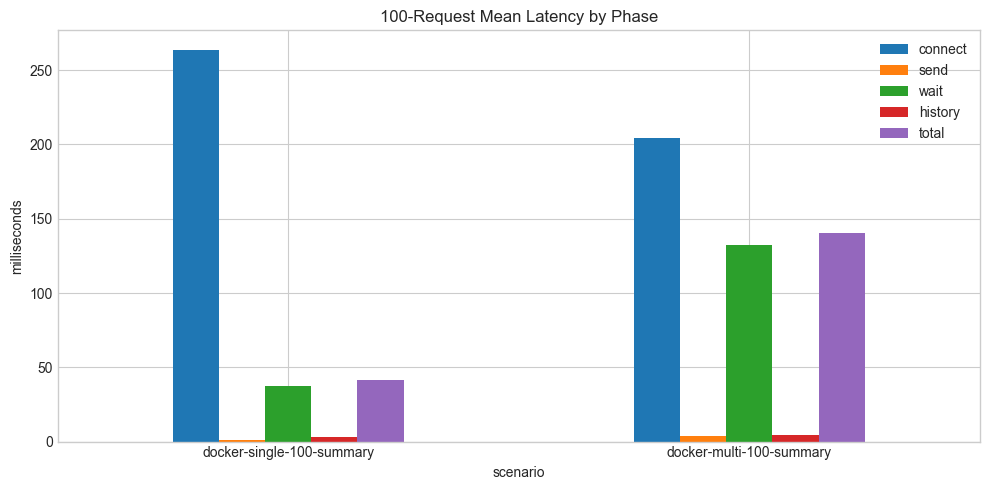

In [33]:
ax = phase_100_df.plot(kind="bar", figsize=(10, 5), rot=0, title="100-Request Mean Latency by Phase")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()

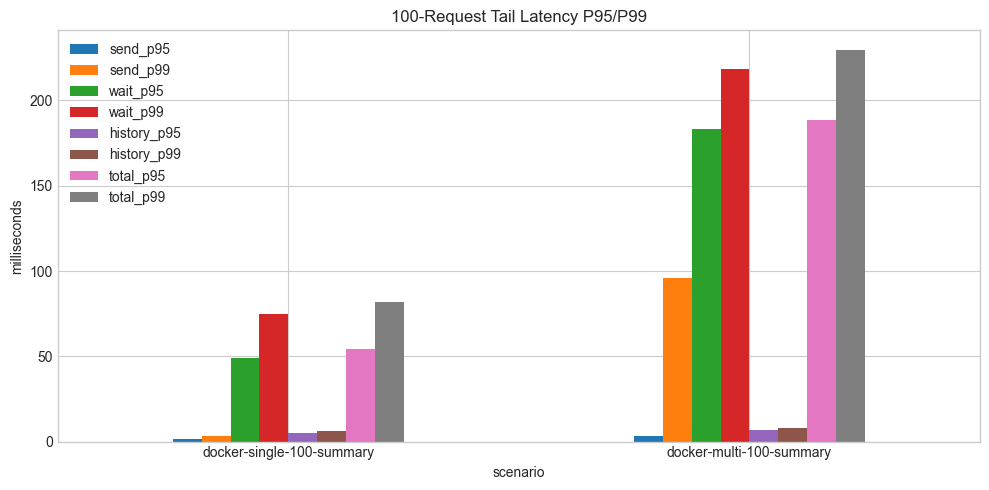

In [34]:
tail_100_9599_df = summary_100_df[["send_p95_ms", "send_p99_ms","wait_p95_ms","wait_p99_ms", "history_p95_ms", "history_p99_ms","total_p95_ms", "total_p99_ms"]].rename(columns={
    "send_p95_ms": "send_p95",
    "send_p99_ms": "send_p99",
    "wait_p95_ms": "wait_p95",
    "wait_p99_ms": "wait_p99",
    "history_p95_ms": "history_p95",
    "history_p99_ms": "history_p99",
    "total_p95_ms": "total_p95",
    "total_p99_ms": "total_p99",
})

ax = tail_100_9599_df.plot(kind="bar", figsize=(10, 5), rot=0, title="100-Request Tail Latency P95/P99")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()

In [35]:
tail_100_df = summary_100_df[["send_p95_ms", "wait_p95_ms", "history_p95_ms", "total_p95_ms"]].rename(columns={
    "send_p95_ms": "send_p95",
    "wait_p95_ms": "wait_p95",
    "history_p95_ms": "history_p95",
    "total_p95_ms": "total_p95",
})

tail_100_df.round(3)

,send_p95,wait_p95,history_p95,total_p95
scenario,,,,
docker-single-100-summary,1.800,48.738,4.937,54.170
docker-multi-100-summary,3.227,183.171,6.610,188.588


In [36]:
tail_100_99_df = summary_100_df[["send_p99_ms", "wait_p99_ms", "history_p99_ms", "total_p99_ms"]].rename(columns={
    "send_p99_ms": "send_p99",
    "wait_p99_ms": "wait_p99",
    "history_p99_ms": "history_p99",
    "total_p99_ms": "total_p99",
})

tail_100_99_df.round(3)

,send_p99,wait_p99,history_p99,total_p99
scenario,,,,
docker-single-100-summary,3.131,74.689,6.265,81.760
docker-multi-100-summary,95.978,218.640,7.987,229.616


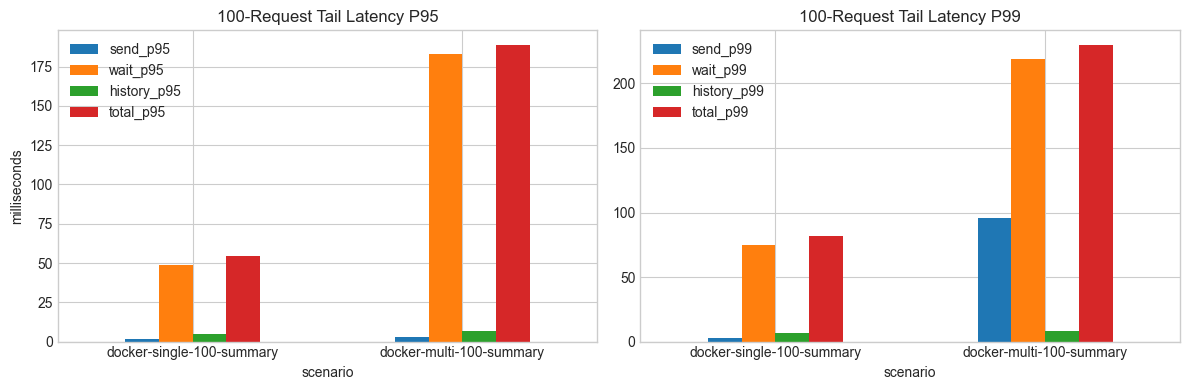

In [37]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tail_100_df.plot(
    kind="bar",
    ax=axes[0],
    rot=0,
    title="100-Request Tail Latency P95",
)

tail_100_99_df.plot(
    kind="bar",
    ax=axes[1],
    rot=0,
    title="100-Request Tail Latency P99",
)
axes[0].set_ylabel("milliseconds")

plt.tight_layout()
plt.show()

In [38]:
semianalysis_100_container_df = semianalysis_100_df[[
    "docker_cpu_percent_mean",
    "docker_mem_percent_mean",
    # "docker_block_read_bytes_mean",
    # "docker_block_write_bytes_mean",
]].rename(columns={
    "docker_cpu_percent_mean": "cpu_percent",
    "docker_mem_percent_mean": "mem_percent",
    # "docker_block_read_bytes_mean": "block_read_bytes",
    # "docker_block_write_bytes_mean": "block_write_bytes",
})

semianalysis_100_container_df.round(3)


,cpu_percent,mem_percent
scenario,,
docker-single-task-semianalysis-100-summary,70.66,20.09
docker-multi-task-semianalysis-100-summary,124.92,19.84


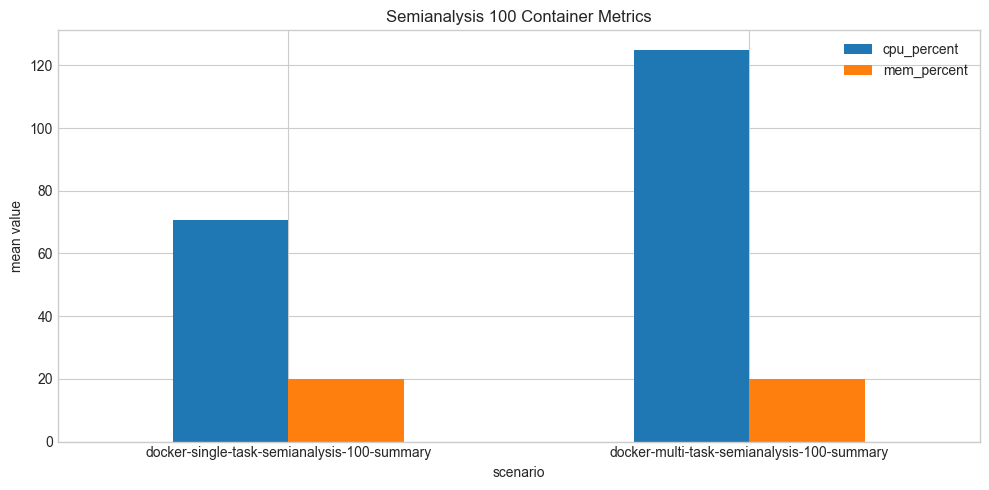

In [39]:
ax = semianalysis_100_container_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100 Container Metrics")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()


## 读取 `resource_profile` 做大样本资源对比图

下面这部分专门读取带资源采集器的 100 次大样本场景：

- `docker-single-resource-profile` (`1 x 100`)
- `docker-multi-resource-profile` (`4 x 25`)

这样可以在对比 `send / wait / history / total` 延迟的同时，一起看：

- `docker_stats`：容器 CPU / 内存 / block IO
- `pidstat`：gateway 进程 CPU / RSS / 写入速率 / iodelay
- `iostat`：最忙磁盘设备的 `%util` / `await` / `aqu-sz` / `wkb/s`


In [8]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / "client-harness" / "out").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the current notebook working directory")


repo_root = resolve_repo_root()
out_root = repo_root / "client-harness" / "out"


def find_latest_run_dir(scenario_name: str) -> Path:
    candidates = sorted(
        [path for path in out_root.iterdir() if path.is_dir() and path.name.endswith(f"_{scenario_name}")],
        key=lambda path: path.name,
    )
    if not candidates:
        raise FileNotFoundError(f"No run directory found for scenario: {scenario_name}")
    return candidates[-1]


def load_summary(run_dir: Path) -> dict:
    return json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))


single_profile_run_dir = find_latest_run_dir("docker-single-resource-profile")
multi_profile_run_dir = find_latest_run_dir("docker-multi-resource-profile")

single_profile_summary = load_summary(single_profile_run_dir)
multi_profile_summary = load_summary(multi_profile_run_dir)

single_profile_run_dir, multi_profile_run_dir


(WindowsPath('//wsl.localhost/Ubuntu/home/z84436644/openclaw/benchmarks/client-harness/out/20260319T172048Z_docker-single-resource-profile'),
 WindowsPath('//wsl.localhost/Ubuntu/home/z84436644/openclaw/benchmarks/client-harness/out/20260319T172048Z_docker-multi-resource-profile'))

In [9]:
single_profile_summary["scenario"], multi_profile_summary["scenario"]


('docker-single-resource-profile', 'docker-multi-resource-profile')

In [10]:
def nested_get(data: dict, path: list[str], default=None):
    current = data
    for key in path:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def metric_mean(data: dict, path: list[str], default=None):
    metric = nested_get(data, path, None)
    if isinstance(metric, dict):
        return metric.get("mean", default)
    return default


def build_resource_profile_row(summary: dict) -> dict:
    latency = summary["latency_ms"]
    docker = nested_get(summary, ["collector_analysis", "docker_stats", "metrics"], {})
    pidstat = nested_get(summary, ["collector_analysis", "pidstat", "sections"], {})
    iostat = nested_get(summary, ["collector_analysis", "iostat"], {})
    busiest_device = iostat.get("busiest_device_by_util_mean")
    device_metrics = nested_get(iostat, ["devices", busiest_device, "metrics"], {}) if busiest_device else {}
    return {
        "scenario": summary["scenario"],
        "requests_total": summary["requests_total"],
        "requests_ok": summary["requests_ok"],
        "requests_failed": summary["requests_failed"],
        "connect_mean_ms": latency["connect"]["mean"],
        "send_mean_ms": latency["send"]["mean"],
        "send_p95_ms": latency["send"]["p95"],
        "send_p99_ms": latency["send"]["p99"],
        "wait_mean_ms": latency["wait"]["mean"],
        "wait_p95_ms": latency["wait"]["p95"],
        "wait_p99_ms": latency["wait"]["p99"],
        "history_mean_ms": latency["history"]["mean"],
        "history_p95_ms": latency["history"]["p95"],
        "history_p99_ms": latency["history"]["p99"],
        "total_mean_ms": latency["total"]["mean"],
        "total_p50_ms": latency["total"]["p50"],
        "total_p95_ms": latency["total"]["p95"],
        "total_p99_ms": latency["total"]["p99"],
        "docker_cpu_percent_mean": metric_mean(docker, ["cpu_percent_value"]),
        "docker_mem_percent_mean": metric_mean(docker, ["mem_percent_value"]),
        "docker_block_read_bytes_mean": metric_mean(docker, ["block_read_bytes"]),
        "docker_block_write_bytes_mean": metric_mean(docker, ["block_write_bytes"]),
        "pidstat_cpu_percent_mean": metric_mean(pidstat, ["cpu", "metrics", "pct_cpu"]),
        "pidstat_rss_kib_mean": metric_mean(pidstat, ["memory", "metrics", "rss_kib"]),
        "pidstat_kb_wr_per_s_mean": metric_mean(pidstat, ["io", "metrics", "kb_wr_per_s"]),
        "pidstat_iodelay_mean": metric_mean(pidstat, ["io", "metrics", "iodelay"]),
        "iostat_busiest_device": busiest_device,
        "iostat_pct_util_mean": metric_mean(device_metrics, ["pct_util"]),
        "iostat_await_mean": metric_mean(device_metrics, ["await"]),
        "iostat_w_await_mean": metric_mean(device_metrics, ["w_await"]),
        "iostat_aqu_sz_mean": metric_mean(device_metrics, ["aqu_sz"]),
        "iostat_wkb_s_mean": metric_mean(device_metrics, ["wkb_s"]),
    }


resource_profile_df = pd.DataFrame([
    build_resource_profile_row(single_profile_summary),
    build_resource_profile_row(multi_profile_summary),
]).set_index("scenario")


In [12]:
resource_profile_df.round(3).T


scenario,docker-single-resource-profile,docker-multi-resource-profile
requests_total,100,100
requests_ok,100,100
requests_failed,0,0
connect_mean_ms,171.907,182.036
send_mean_ms,1.032,2.397
send_p95_ms,1.511,2.342
send_p99_ms,2.393,19.044
wait_mean_ms,35.84,132.08
wait_p95_ms,48.043,161.007
wait_p99_ms,70.107,243.795


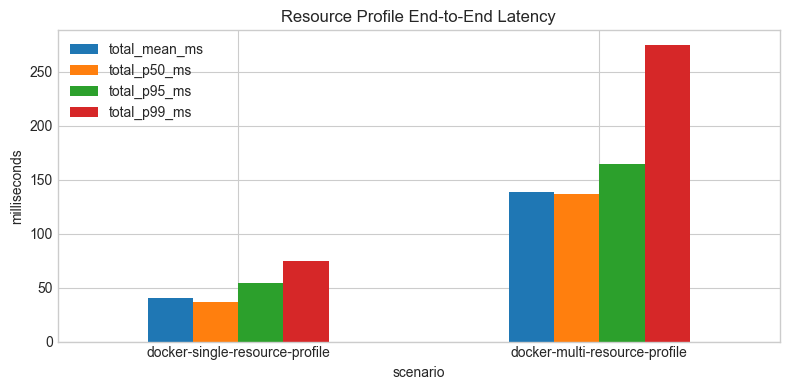

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 1, figsize=(8, 4))

resource_profile_df[["total_mean_ms", "total_p50_ms", "total_p95_ms", "total_p99_ms"]].plot(
    kind="bar",
    ax=axes,
    rot=0,
    title="Resource Profile End-to-End Latency",
)
axes.set_ylabel("milliseconds")

plt.tight_layout()
plt.show()


In [6]:
resource_phase_df = resource_profile_df[[
    "connect_mean_ms",
    "send_mean_ms",
    "wait_mean_ms",
    "history_mean_ms",
    "total_mean_ms",
]].rename(columns={
    "connect_mean_ms": "connect",
    "send_mean_ms": "send",
    "wait_mean_ms": "wait",
    "history_mean_ms": "history",
    "total_mean_ms": "total",
})

resource_phase_df.round(3)


,connect,send,wait,history,total
scenario,,,,,
docker-single-resource-profile,171.907,1.032,35.84,3.064,39.959
docker-multi-resource-profile,182.036,2.397,132.08,4.145,138.647


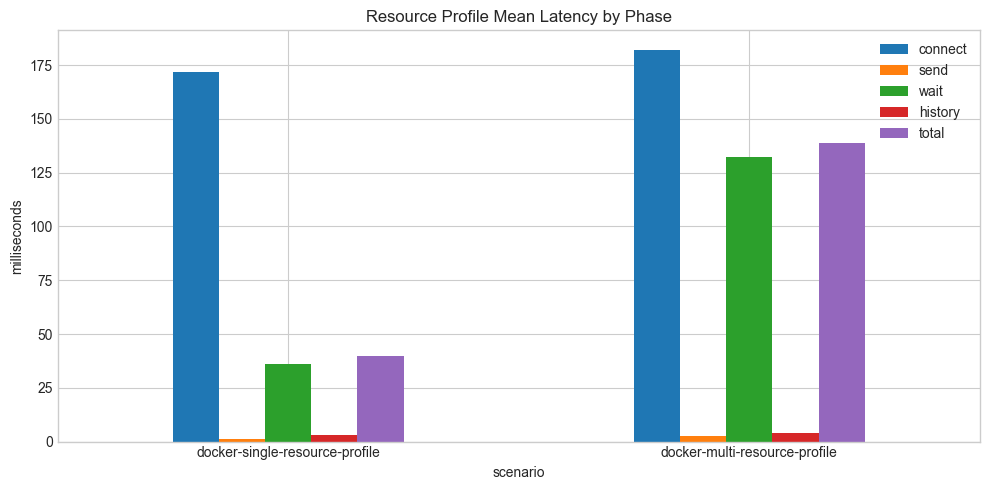

In [7]:
ax = resource_phase_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Resource Profile Mean Latency by Phase")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()


In [8]:
resource_tail_df = resource_profile_df[["send_p95_ms", "send_p99_ms", "wait_p95_ms", "wait_p99_ms", "history_p95_ms", "history_p99_ms", "total_p95_ms", "total_p99_ms"]].rename(columns={
    "send_p95_ms": "send_p95",
    "send_p99_ms": "send_p99",
    "wait_p95_ms": "wait_p95",
    "wait_p99_ms": "wait_p99",
    "history_p95_ms": "history_p95",
    "history_p99_ms": "history_p99",
    "total_p95_ms": "total_p95",
    "total_p99_ms": "total_p99",
})

resource_tail_df.round(3)


,send_p95,send_p99,wait_p95,wait_p99,history_p95,history_p99,total_p95,total_p99
scenario,,,,,,,,
docker-single-resource-profile,1.511,2.393,48.043,70.107,4.406,5.252,54.014,74.856
docker-multi-resource-profile,2.342,19.044,161.007,243.795,6.415,12.113,164.662,274.663


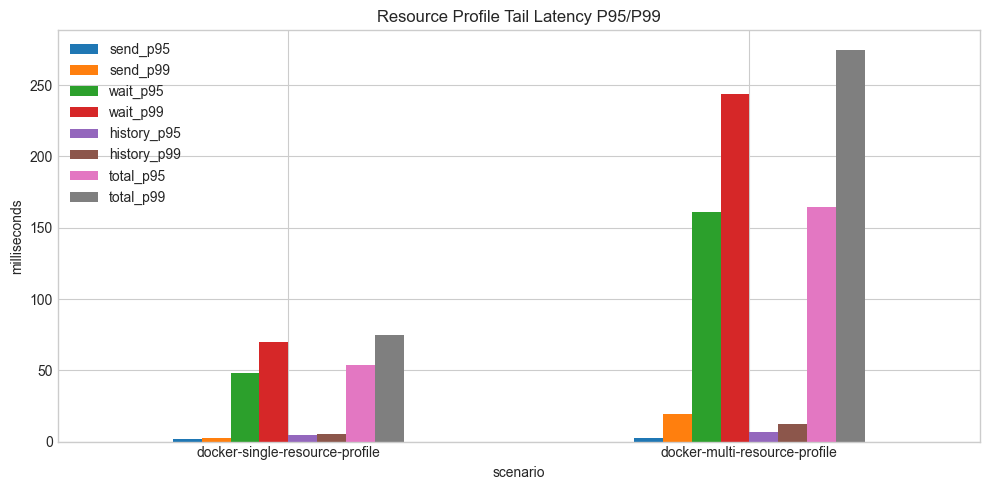

In [9]:
ax = resource_tail_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Resource Profile Tail Latency P95/P99")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()


In [21]:
resource_container_df = resource_profile_df[[
    "docker_cpu_percent_mean",
    "docker_mem_percent_mean",
    "docker_block_read_bytes_mean",
    # "docker_block_write_bytes_mean",
]].rename(columns={
    "docker_cpu_percent_mean": "cpu_percent",
    "docker_mem_percent_mean": "mem_percent",
    "docker_block_read_bytes_mean": "block_read_bytes",
    # "docker_block_write_bytes_mean": "block_write_bytes",
})

resource_container_df.round(3)


,cpu_percent,mem_percent,block_read_bytes
scenario,,,
docker-single-resource-profile,118.845,19.865,0.0
docker-multi-resource-profile,58.420,19.845,4100.0


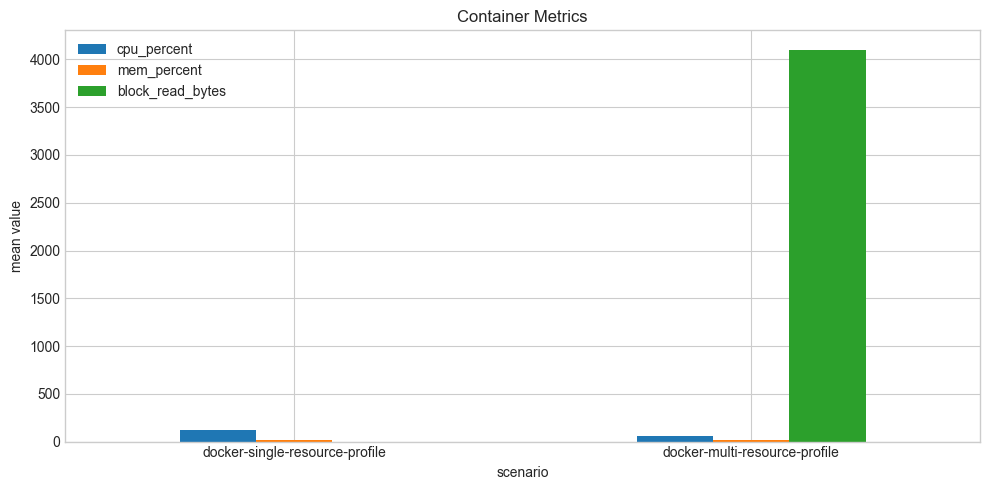

In [22]:
ax = resource_container_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Container Metrics")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()


In [12]:
resource_process_df = resource_profile_df[[
    "pidstat_cpu_percent_mean",
    "pidstat_rss_kib_mean",
    "pidstat_kb_wr_per_s_mean",
    "pidstat_iodelay_mean",
]].rename(columns={
    "pidstat_cpu_percent_mean": "cpu_percent",
    "pidstat_rss_kib_mean": "rss_kib",
    "pidstat_kb_wr_per_s_mean": "kb_wr_per_s",
    "pidstat_iodelay_mean": "iodelay",
})

resource_process_df.round(3)


,cpu_percent,rss_kib,kb_wr_per_s,iodelay
scenario,,,,
docker-single-resource-profile,0.0,640.0,0.0,0.0
docker-multi-resource-profile,0.0,640.0,0.0,0.0


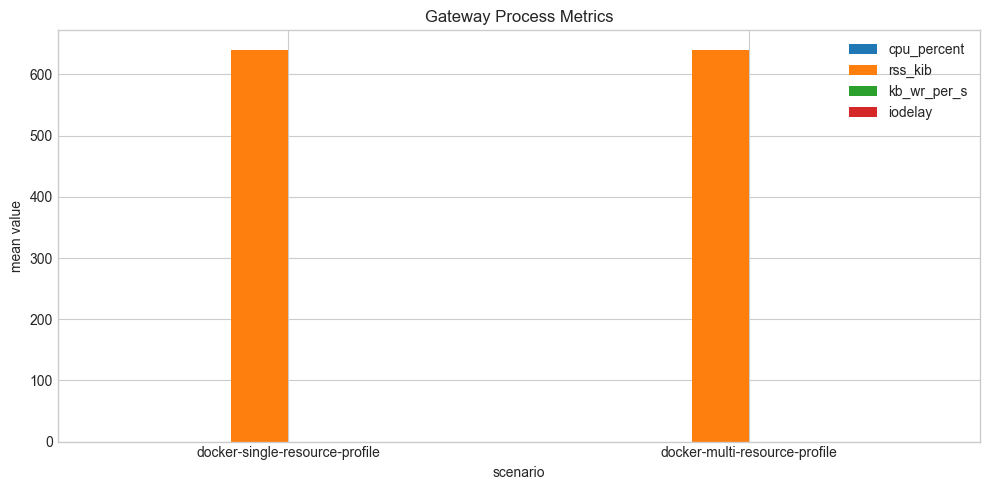

In [13]:
ax = resource_process_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Gateway Process Metrics")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()


In [14]:
resource_disk_df = resource_profile_df[[
    "iostat_busiest_device",
    "iostat_pct_util_mean",
    "iostat_await_mean",
    "iostat_w_await_mean",
    "iostat_aqu_sz_mean",
    "iostat_wkb_s_mean",
]].rename(columns={
    "iostat_busiest_device": "busiest_device",
    "iostat_pct_util_mean": "pct_util",
    "iostat_await_mean": "await",
    "iostat_w_await_mean": "w_await",
    "iostat_aqu_sz_mean": "aqu_sz",
    "iostat_wkb_s_mean": "wkb_s",
})

resource_disk_df.round(3)


,busiest_device,pct_util,await,w_await,aqu_sz,wkb_s
scenario,,,,,,
docker-single-resource-profile,sdd,2.8,None,0.482,0.028,405.0
docker-multi-resource-profile,sdd,2.8,None,0.480,0.028,405.0


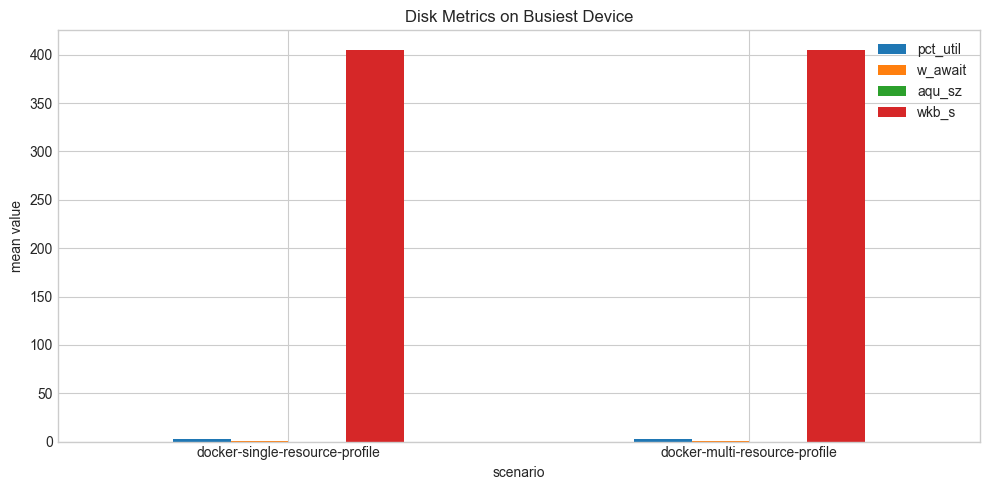

In [15]:
resource_disk_plot_df = resource_disk_df.drop(columns=["busiest_device"])

ax = resource_disk_plot_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Disk Metrics on Busiest Device")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()


## 读取 `semianalysis_100_summary` 做大样本对比图

下面这部分专门读取网页标题抓取任务的 100 次大样本场景：

- `docker-single-task-semianalysis-100-summary` (`1 x 100`)
- `docker-multi-task-semianalysis-100-summary` (`4 x 25`)

这样可以更稳定地比较 semianalysis prompt 在单 worker 和多 worker 下的延迟分布。


In [16]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / "client-harness" / "out").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the current notebook working directory")


repo_root = resolve_repo_root()
out_root = repo_root / "client-harness" / "out"


def find_latest_run_dir(scenario_name: str) -> Path:
    candidates = sorted(
        [path for path in out_root.iterdir() if path.is_dir() and path.name.endswith(f"_{scenario_name}")],
        key=lambda path: path.name,
    )
    if not candidates:
        raise FileNotFoundError(f"No run directory found for scenario: {scenario_name}")
    return candidates[-1]


def load_summary(run_dir: Path) -> dict:
    return json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))


single_semianalysis_100_run_dir = find_latest_run_dir("docker-single-task-semianalysis-100-summary")
multi_semianalysis_100_run_dir = find_latest_run_dir("docker-multi-task-semianalysis-100-summary")

single_semianalysis_100_summary = load_summary(single_semianalysis_100_run_dir)
multi_semianalysis_100_summary = load_summary(multi_semianalysis_100_run_dir)

single_semianalysis_100_run_dir, multi_semianalysis_100_run_dir


(WindowsPath('//wsl.localhost/Ubuntu/home/z84436644/openclaw/benchmarks/client-harness/out/20260320T093005Z_docker-single-task-semianalysis-100-summary'),
 WindowsPath('//wsl.localhost/Ubuntu/home/z84436644/openclaw/benchmarks/client-harness/out/20260320T093039Z_docker-multi-task-semianalysis-100-summary'))

In [2]:
def nested_get(data: dict, path: list[str], default=None):
    current = data
    for key in path:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def metric_mean(data: dict, path: list[str], default=None):
    metric = nested_get(data, path, None)
    if isinstance(metric, dict):
        return metric.get("mean", default)
    return default


def build_semianalysis_100_row(summary: dict) -> dict:
    latency = summary["latency_ms"]
    task = summary.get("task", {})
    docker = nested_get(summary, ["collector_analysis", "docker_stats", "metrics"], {})
    pidstat = nested_get(summary, ["collector_analysis", "pidstat", "sections"], {})
    iostat = nested_get(summary, ["collector_analysis", "iostat"], {})
    busiest_device = iostat.get("busiest_device_by_util_mean")
    device_metrics = nested_get(iostat, ["devices", busiest_device, "metrics"], {}) if busiest_device else {}
    return {
        "scenario": summary["scenario"],
        "task_id": task.get("id", ""),
        "task_name": task.get("name", ""),
        "requests_total": summary["requests_total"],
        "requests_ok": summary["requests_ok"],
        "requests_failed": summary["requests_failed"],
        "connect_mean_ms": latency["connect"]["mean"],
        "send_mean_ms": latency["send"]["mean"],
        "send_p95_ms": latency["send"]["p95"],
        "send_p99_ms": latency["send"]["p99"],
        "wait_mean_ms": latency["wait"]["mean"],
        "wait_p95_ms": latency["wait"]["p95"],
        "wait_p99_ms": latency["wait"]["p99"],
        "history_mean_ms": latency["history"]["mean"],
        "history_p95_ms": latency["history"]["p95"],
        "history_p99_ms": latency["history"]["p99"],
        "total_mean_ms": latency["total"]["mean"],
        "total_p50_ms": latency["total"]["p50"],
        "total_p95_ms": latency["total"]["p95"],
        "total_p99_ms": latency["total"]["p99"],
        "docker_cpu_percent_mean": metric_mean(docker, ["cpu_percent_value"]),
        "docker_mem_percent_mean": metric_mean(docker, ["mem_percent_value"]),
        "docker_block_read_bytes_mean": metric_mean(docker, ["block_read_bytes"]),
        "docker_block_write_bytes_mean": metric_mean(docker, ["block_write_bytes"]),
        "pidstat_cpu_percent_mean": metric_mean(pidstat, ["cpu", "metrics", "pct_cpu"]),
        "pidstat_rss_kib_mean": metric_mean(pidstat, ["memory", "metrics", "rss_kib"]),
        "pidstat_kb_wr_per_s_mean": metric_mean(pidstat, ["io", "metrics", "kb_wr_per_s"]),
        "pidstat_iodelay_mean": metric_mean(pidstat, ["io", "metrics", "iodelay"]),
        "iostat_busiest_device": busiest_device,
        "iostat_pct_util_mean": metric_mean(device_metrics, ["pct_util"]),
        "iostat_await_mean": metric_mean(device_metrics, ["await"]),
        "iostat_w_await_mean": metric_mean(device_metrics, ["w_await"]),
        "iostat_aqu_sz_mean": metric_mean(device_metrics, ["aqu_sz"]),
        "iostat_wkb_s_mean": metric_mean(device_metrics, ["wkb_s"]),
    }


semianalysis_100_df = pd.DataFrame([
    build_semianalysis_100_row(single_semianalysis_100_summary),
    build_semianalysis_100_row(multi_semianalysis_100_summary),
]).set_index("scenario")

semianalysis_100_df.round(3)


,task_id,task_name,requests_total,requests_ok,requests_failed,connect_mean_ms,send_mean_ms,send_p95_ms,send_p99_ms,wait_mean_ms,...,pidstat_cpu_percent_mean,pidstat_rss_kib_mean,pidstat_kb_wr_per_s_mean,pidstat_iodelay_mean,iostat_busiest_device,iostat_pct_util_mean,iostat_await_mean,iostat_w_await_mean,iostat_aqu_sz_mean,iostat_wkb_s_mean
scenario,,,,,,,,,,,,,,,,,,,,,
docker-single-task-semianalysis-100-summary,task_05_semianalysis_title,Semianalysis Title Fetch,100,100,0,198.264,0.756,1.042,2.323,14.391,...,0.0,640.0,0.0,0.0,sdd,8.8,None,0.250,0.12,352.0
docker-multi-task-semianalysis-100-summary,task_05_semianalysis_title,Semianalysis Title Fetch,100,100,0,111.254,1.067,2.118,3.385,59.846,...,0.0,640.0,0.0,0.0,sdd,2.2,None,0.745,0.07,6940.0


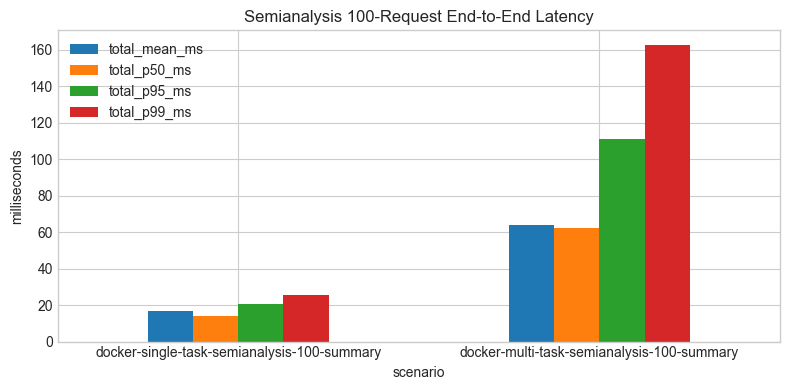

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 1, figsize=(8, 4))

semianalysis_100_df[["total_mean_ms", "total_p50_ms", "total_p95_ms", "total_p99_ms"]].plot(
    kind="bar",
    ax=axes,
    rot=0,
    title="Semianalysis 100-Request End-to-End Latency",
)
axes.set_ylabel("milliseconds")

plt.tight_layout()
plt.show()


In [4]:
semianalysis_100_phase_df = semianalysis_100_df[[
    "connect_mean_ms",
    "send_mean_ms",
    "wait_mean_ms",
    "history_mean_ms",
    "total_mean_ms",
]].rename(columns={
    "connect_mean_ms": "connect",
    "send_mean_ms": "send",
    "wait_mean_ms": "wait",
    "history_mean_ms": "history",
    "total_mean_ms": "total",
})

semianalysis_100_phase_df.round(3)


,connect,send,wait,history,total
scenario,,,,,
docker-single-task-semianalysis-100-summary,198.264,0.756,14.391,1.540,16.706
docker-multi-task-semianalysis-100-summary,111.254,1.067,59.846,3.198,64.131


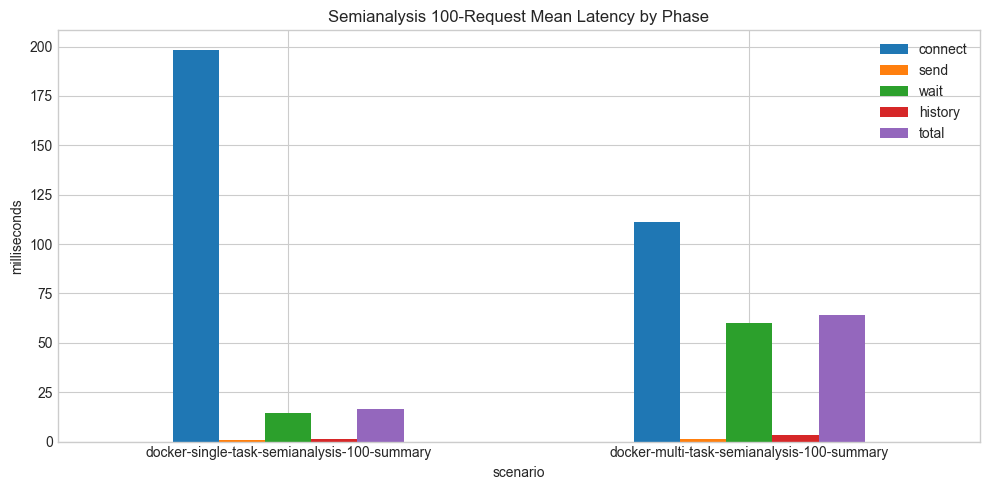

In [5]:
ax = semianalysis_100_phase_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100-Request Mean Latency by Phase")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()


In [6]:
semianalysis_100_tail_df = semianalysis_100_df[["send_p95_ms", "send_p99_ms", "wait_p95_ms", "wait_p99_ms", "history_p95_ms", "history_p99_ms", "total_p95_ms", "total_p99_ms"]].rename(columns={
    "send_p95_ms": "send_p95",
    "send_p99_ms": "send_p99",
    "wait_p95_ms": "wait_p95",
    "wait_p99_ms": "wait_p99",
    "history_p95_ms": "history_p95",
    "history_p99_ms": "history_p99",
    "total_p95_ms": "total_p95",
    "total_p99_ms": "total_p99",
})

semianalysis_100_tail_df.round(3)


,send_p95,send_p99,wait_p95,wait_p99,history_p95,history_p99,total_p95,total_p99
scenario,,,,,,,,
docker-single-task-semianalysis-100-summary,1.042,2.323,17.059,23.325,2.070,6.697,20.415,25.454
docker-multi-task-semianalysis-100-summary,2.118,3.385,96.516,155.380,4.596,7.110,111.118,162.370


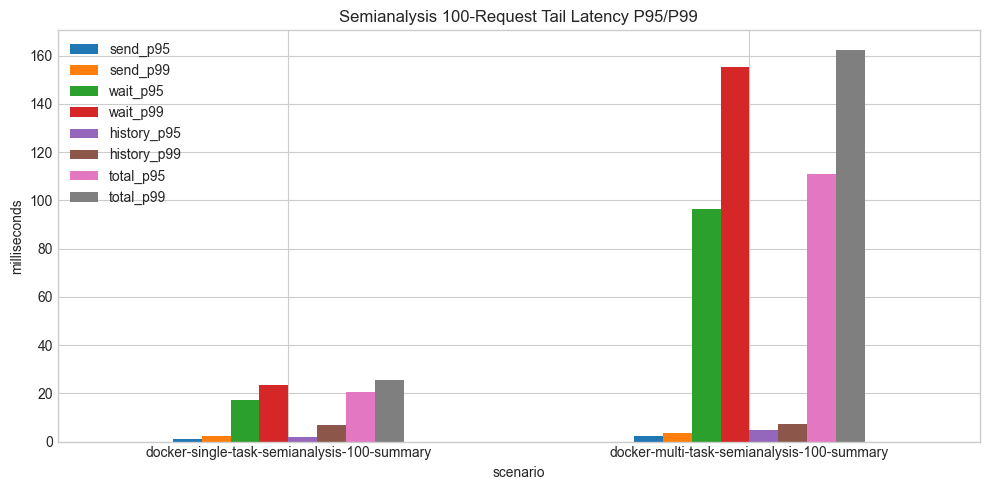

In [7]:
ax = semianalysis_100_tail_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100-Request Tail Latency P95/P99")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()


In [8]:
semianalysis_100_container_df = semianalysis_100_df[[
    "docker_cpu_percent_mean",
    "docker_mem_percent_mean",
    "docker_block_read_bytes_mean",
    "docker_block_write_bytes_mean",
]].rename(columns={
    "docker_cpu_percent_mean": "cpu_percent",
    "docker_mem_percent_mean": "mem_percent",
    "docker_block_read_bytes_mean": "block_read_bytes",
    "docker_block_write_bytes_mean": "block_write_bytes",
})

semianalysis_100_container_df.round(3)


,cpu_percent,mem_percent,block_read_bytes,block_write_bytes
scenario,,,,
docker-single-task-semianalysis-100-summary,110.51,23.22,67500000.0,11200000.0
docker-multi-task-semianalysis-100-summary,124.39,19.98,0.0,12000000.0


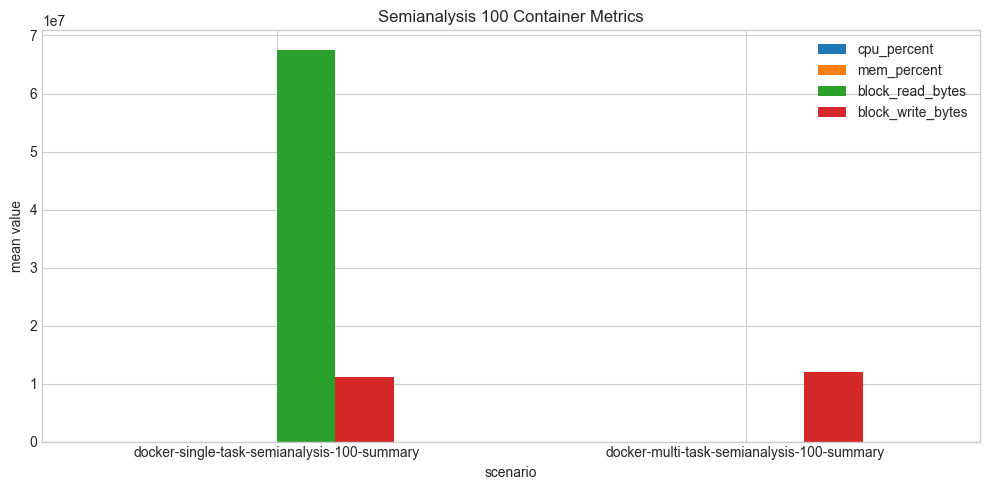

In [9]:
ax = semianalysis_100_container_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100 Container Metrics")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()


In [10]:
semianalysis_100_process_df = semianalysis_100_df[[
    "pidstat_cpu_percent_mean",
    "pidstat_rss_kib_mean",
    "pidstat_kb_wr_per_s_mean",
    "pidstat_iodelay_mean",
]].rename(columns={
    "pidstat_cpu_percent_mean": "cpu_percent",
    "pidstat_rss_kib_mean": "rss_kib",
    "pidstat_kb_wr_per_s_mean": "kb_wr_per_s",
    "pidstat_iodelay_mean": "iodelay",
})

semianalysis_100_process_df.round(3)


,cpu_percent,rss_kib,kb_wr_per_s,iodelay
scenario,,,,
docker-single-task-semianalysis-100-summary,0.0,640.0,0.0,0.0
docker-multi-task-semianalysis-100-summary,0.0,640.0,0.0,0.0


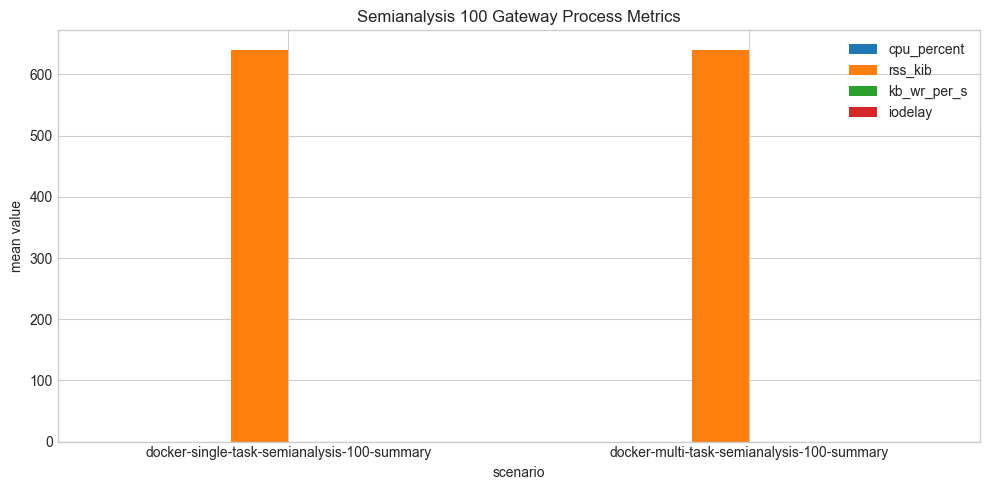

In [11]:
ax = semianalysis_100_process_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100 Gateway Process Metrics")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()


In [12]:
semianalysis_100_disk_df = semianalysis_100_df[[
    "iostat_busiest_device",
    "iostat_pct_util_mean",
    "iostat_await_mean",
    "iostat_w_await_mean",
    "iostat_aqu_sz_mean",
    "iostat_wkb_s_mean",
]].rename(columns={
    "iostat_busiest_device": "busiest_device",
    "iostat_pct_util_mean": "pct_util",
    "iostat_await_mean": "await",
    "iostat_w_await_mean": "w_await",
    "iostat_aqu_sz_mean": "aqu_sz",
    "iostat_wkb_s_mean": "wkb_s",
})

semianalysis_100_disk_df.round(3)


,busiest_device,pct_util,await,w_await,aqu_sz,wkb_s
scenario,,,,,,
docker-single-task-semianalysis-100-summary,sdd,8.8,None,0.250,0.12,352.0
docker-multi-task-semianalysis-100-summary,sdd,2.2,None,0.745,0.07,6940.0


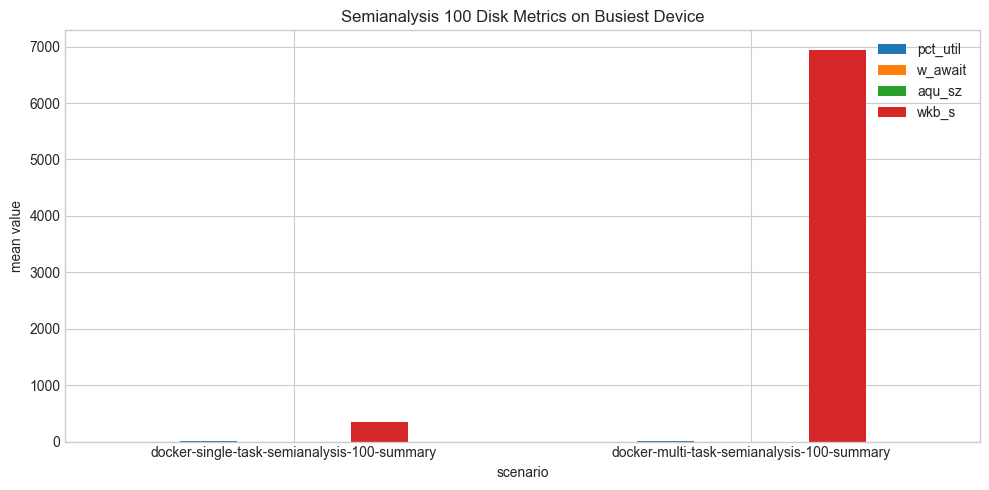

In [13]:
semianalysis_100_disk_plot_df = semianalysis_100_disk_df.drop(columns=["busiest_device"])

ax = semianalysis_100_disk_plot_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100 Disk Metrics on Busiest Device")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()


## Semianalysis-100 rerun

In [19]:
def nested_get(data: dict, path: list[str], default=None):
    current = data
    for key in path:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def metric_mean(data: dict, path: list[str], default=None):
    metric = nested_get(data, path, None)
    if isinstance(metric, dict):
        return metric.get("mean", default)
    return default


def build_semianalysis_100_row(summary: dict) -> dict:
    latency = summary["latency_ms"]
    task = summary.get("task", {})
    docker = nested_get(summary, ["collector_analysis", "docker_stats", "metrics"], {})
    pidstat = nested_get(summary, ["collector_analysis", "pidstat", "sections"], {})
    iostat = nested_get(summary, ["collector_analysis", "iostat"], {})
    busiest_device = iostat.get("busiest_device_by_util_mean")
    device_metrics = nested_get(iostat, ["devices", busiest_device, "metrics"], {}) if busiest_device else {}
    return {
        "scenario": summary["scenario"],
        "task_id": task.get("id", ""),
        "task_name": task.get("name", ""),
        "requests_total": summary["requests_total"],
        "requests_ok": summary["requests_ok"],
        "requests_failed": summary["requests_failed"],
        "connect_mean_ms": latency["connect"]["mean"],
        "send_mean_ms": latency["send"]["mean"],
        "send_p95_ms": latency["send"]["p95"],
        "send_p99_ms": latency["send"]["p99"],
        "wait_mean_ms": latency["wait"]["mean"],
        "wait_p95_ms": latency["wait"]["p95"],
        "wait_p99_ms": latency["wait"]["p99"],
        "history_mean_ms": latency["history"]["mean"],
        "history_p95_ms": latency["history"]["p95"],
        "history_p99_ms": latency["history"]["p99"],
        "total_mean_ms": latency["total"]["mean"],
        "total_p50_ms": latency["total"]["p50"],
        "total_p95_ms": latency["total"]["p95"],
        "total_p99_ms": latency["total"]["p99"],
        "docker_cpu_percent_mean": metric_mean(docker, ["cpu_percent_value"]),
        "docker_mem_percent_mean": metric_mean(docker, ["mem_percent_value"]),
        "docker_block_read_bytes_mean": metric_mean(docker, ["block_read_bytes"]),
        "docker_block_write_bytes_mean": metric_mean(docker, ["block_write_bytes"]),
        "pidstat_cpu_percent_mean": metric_mean(pidstat, ["cpu", "metrics", "pct_cpu"]),
        "pidstat_rss_kib_mean": metric_mean(pidstat, ["memory", "metrics", "rss_kib"]),
        "pidstat_kb_wr_per_s_mean": metric_mean(pidstat, ["io", "metrics", "kb_wr_per_s"]),
        "pidstat_iodelay_mean": metric_mean(pidstat, ["io", "metrics", "iodelay"]),
        "iostat_busiest_device": busiest_device,
        "iostat_pct_util_mean": metric_mean(device_metrics, ["pct_util"]),
        "iostat_await_mean": metric_mean(device_metrics, ["await"]),
        "iostat_w_await_mean": metric_mean(device_metrics, ["w_await"]),
        "iostat_aqu_sz_mean": metric_mean(device_metrics, ["aqu_sz"]),
        "iostat_wkb_s_mean": metric_mean(device_metrics, ["wkb_s"]),
    }


semianalysis_100_df = pd.DataFrame([
    build_semianalysis_100_row(single_semianalysis_100_summary),
    build_semianalysis_100_row(multi_semianalysis_100_summary),
]).set_index("scenario")

semianalysis_100_df.round(3).T


scenario,docker-single-task-semianalysis-100-summary,docker-multi-task-semianalysis-100-summary
task_id,task_05_semianalysis_title,task_05_semianalysis_title
task_name,Semianalysis Title Fetch,Semianalysis Title Fetch
requests_total,100,100
requests_ok,100,100
requests_failed,0,0
connect_mean_ms,244.257,135.892
send_mean_ms,1.067,3.7
send_p95_ms,1.471,2.839
send_p99_ms,1.951,101.959
wait_mean_ms,23.816,68.266


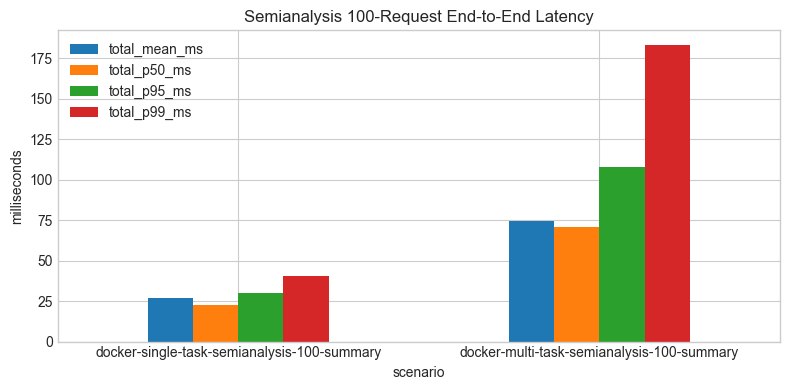

In [20]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 1, figsize=(8, 4))

semianalysis_100_df[["total_mean_ms", "total_p50_ms", "total_p95_ms", "total_p99_ms"]].plot(
    kind="bar",
    ax=axes,
    rot=0,
    title="Semianalysis 100-Request End-to-End Latency",
)
axes.set_ylabel("milliseconds")

plt.tight_layout()
plt.show()


In [21]:
semianalysis_100_phase_df = semianalysis_100_df[[
    "connect_mean_ms",
    "send_mean_ms",
    "wait_mean_ms",
    "history_mean_ms",
    "total_mean_ms",
]].rename(columns={
    "connect_mean_ms": "connect",
    "send_mean_ms": "send",
    "wait_mean_ms": "wait",
    "history_mean_ms": "history",
    "total_mean_ms": "total",
})

semianalysis_100_phase_df.round(3)


,connect,send,wait,history,total
scenario,,,,,
docker-single-task-semianalysis-100-summary,244.257,1.067,23.816,2.254,27.162
docker-multi-task-semianalysis-100-summary,135.892,3.700,68.266,2.431,74.420


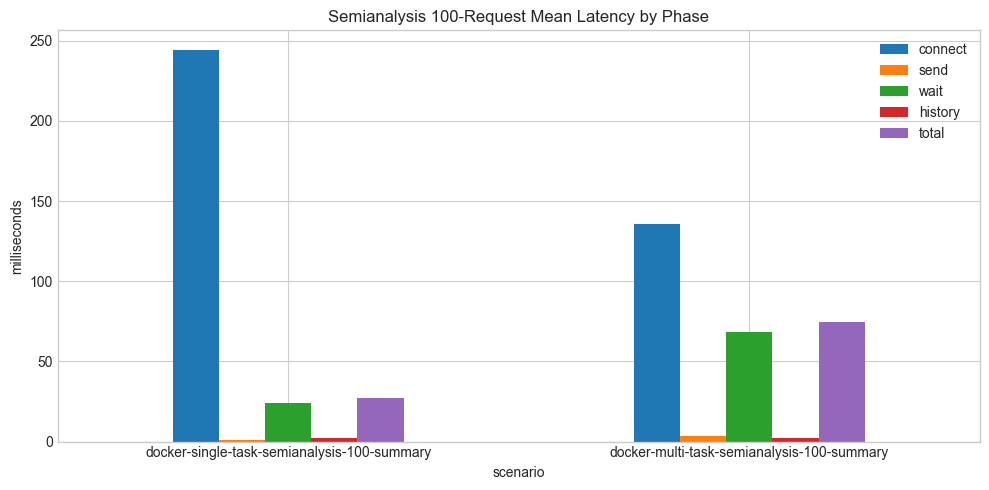

In [22]:
ax = semianalysis_100_phase_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100-Request Mean Latency by Phase")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()


In [23]:
semianalysis_100_tail_df = semianalysis_100_df[["send_p95_ms", "send_p99_ms", "wait_p95_ms", "wait_p99_ms", "history_p95_ms", "history_p99_ms", "total_p95_ms", "total_p99_ms"]].rename(columns={
    "send_p95_ms": "send_p95",
    "send_p99_ms": "send_p99",
    "wait_p95_ms": "wait_p95",
    "wait_p99_ms": "wait_p99",
    "history_p95_ms": "history_p95",
    "history_p99_ms": "history_p99",
    "total_p95_ms": "total_p95",
    "total_p99_ms": "total_p99",
})

semianalysis_100_tail_df.round(3)


,send_p95,send_p99,wait_p95,wait_p99,history_p95,history_p99,total_p95,total_p99
scenario,,,,,,,,
docker-single-task-semianalysis-100-summary,1.471,1.951,26.818,34.409,3.934,9.261,29.984,40.586
docker-multi-task-semianalysis-100-summary,2.839,101.959,100.365,179.948,6.058,6.862,107.764,183.161


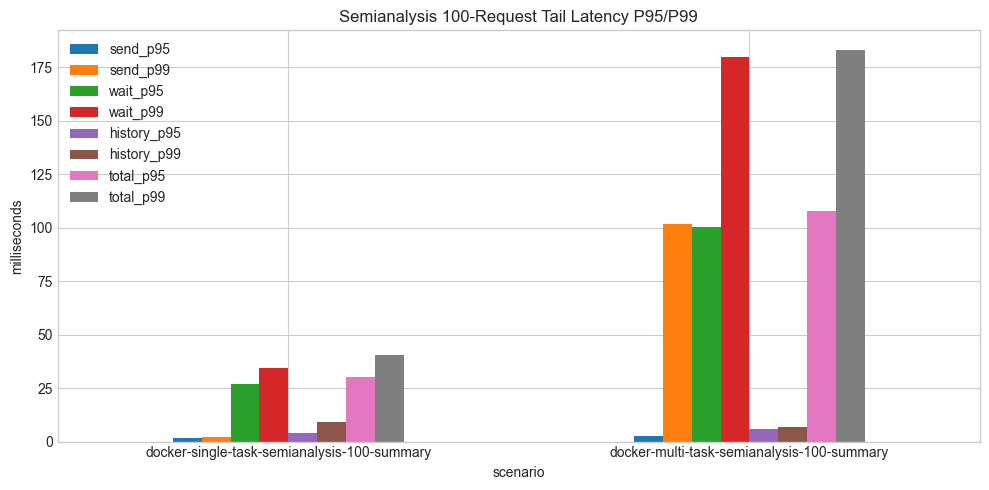

In [24]:
ax = semianalysis_100_tail_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100-Request Tail Latency P95/P99")
ax.set_ylabel("milliseconds")
plt.tight_layout()
plt.show()


In [27]:
semianalysis_100_container_df = semianalysis_100_df[[
    "docker_cpu_percent_mean",
    "docker_mem_percent_mean",
    # "docker_block_read_bytes_mean",
    # "docker_block_write_bytes_mean",
]].rename(columns={
    "docker_cpu_percent_mean": "cpu_percent",
    "docker_mem_percent_mean": "mem_percent",
    # "docker_block_read_bytes_mean": "block_read_bytes",
    # "docker_block_write_bytes_mean": "block_write_bytes",
})

semianalysis_100_container_df.round(3)


,cpu_percent,mem_percent
scenario,,
docker-single-task-semianalysis-100-summary,70.66,20.09
docker-multi-task-semianalysis-100-summary,124.92,19.84


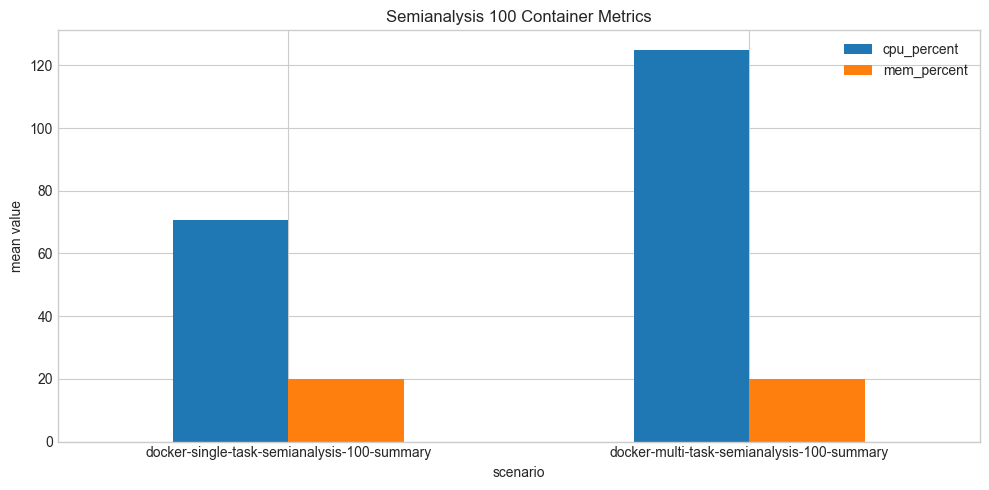

In [28]:
ax = semianalysis_100_container_df.plot(kind="bar", figsize=(10, 5), rot=0, title="Semianalysis 100 Container Metrics")
ax.set_ylabel("mean value")
plt.tight_layout()
plt.show()
